# Theorem 11 — Inverse Approximation and Exponential Decay

This notebook illustrates the inverse approximation statement for stable linear continuous-time RNNs.

The numerical experiment compares:

1. an exponentially decaying target;
2. a polynomially decaying target;
3. fixed versus shrinking stability gaps.

**Source:** Li, Han, E, and Li (2022), *Approximation and Optimization Theory for Linear Continuous-Time RNNs*, Theorem 11.


## 1. Theorem and experimental scope

For the constant input $e_i$, define

$$
y_i(t)=H_t(e_i).
$$

Theorem 11 states that if the derivatives $y_i^{(k)}$ can be approximated uniformly on $[0,\infty)$ by linear RNNs whose parameters remain uniformly bounded and whose state matrices possess a common stability margin, then

$$
e^{\beta t}y_i^{(k)}(t)\to 0
\qquad
(t\to\infty).
$$

Equivalently,

$$
y_i^{(k)}(t)=o(e^{-\beta t}).
$$

The experiment does not prove the theorem. It illustrates why the common stability gap is essential.

**Source:** Li et al. (2022), Theorem 11 and its proof.


## 2. Numerical approximation model

We approximate a target kernel $\rho$ by

$$
\widehat\rho_m(t)
=
\sum_{j=1}^m a_j e^{-\lambda_j t}.
$$

For fixed rates $\lambda_j$, the coefficients are found by discrete least squares:

$$
\min_{a\in\mathbb R^m}
\|\Phi a-r\|_2^2,
\qquad
\Phi_{ij}=e^{-\lambda_j t_i}.
$$

Two rate families are compared:

- **fixed gap:** $\lambda_j\ge\beta+\delta$;
- **shrinking gap:** $\lambda_{\min}(m)=1/m$.

The first satisfies a common stability margin. The second allows increasingly slow time scales as $m$ grows.


## 3. Load saved experiment results


In [21]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve().parent

FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLE_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "tables"
    / "theorem11_inverse_decay_results.csv"
)

results = pd.read_csv(TABLE_PATH)
results


,width,exponential_fixed_gap_error,polynomial_fixed_gap_error,polynomial_shrinking_gap_error,shrinking_gap_lambda_min
0,2,1.049484e-01,0.062161,3.181705e-01,0.500000
1,3,4.748446e-02,0.066869,4.863566e-02,0.333333
2,5,5.370102e-03,0.052703,2.008098e-03,0.200000
3,8,7.995522e-05,0.026870,2.855385e-04,0.125000
4,10,1.399187e-08,0.018135,4.450707e-05,0.100000
5,15,2.008813e-08,0.009562,5.053517e-08,0.066667
6,20,1.402256e-11,0.006055,9.087620e-12,0.050000
7,30,3.343992e-13,0.004668,6.583623e-14,0.033333


## 4. Fixed stability gap: target comparison

The first figure compares

$$
\rho_{\exp}(t)=e^{-2t},
\qquad
\rho_{\mathrm{poly}}(t)=\frac{1}{(1+t)^2}.
$$

Both targets are approximated by exponential sums whose decay rates satisfy $\lambda_j\ge\beta$.

For each width $m$, the plot shows the maximum absolute kernel error on the discretized interval $[0,20]$:

$$
E_m
=
\max_{t\in[0,20]}
\left|
\rho(t)-\widehat\rho_m(t)
\right|.
$$

The horizontal axis is the RNN width $m$, while the vertical axis shows $E_m$ on a logarithmic scale.

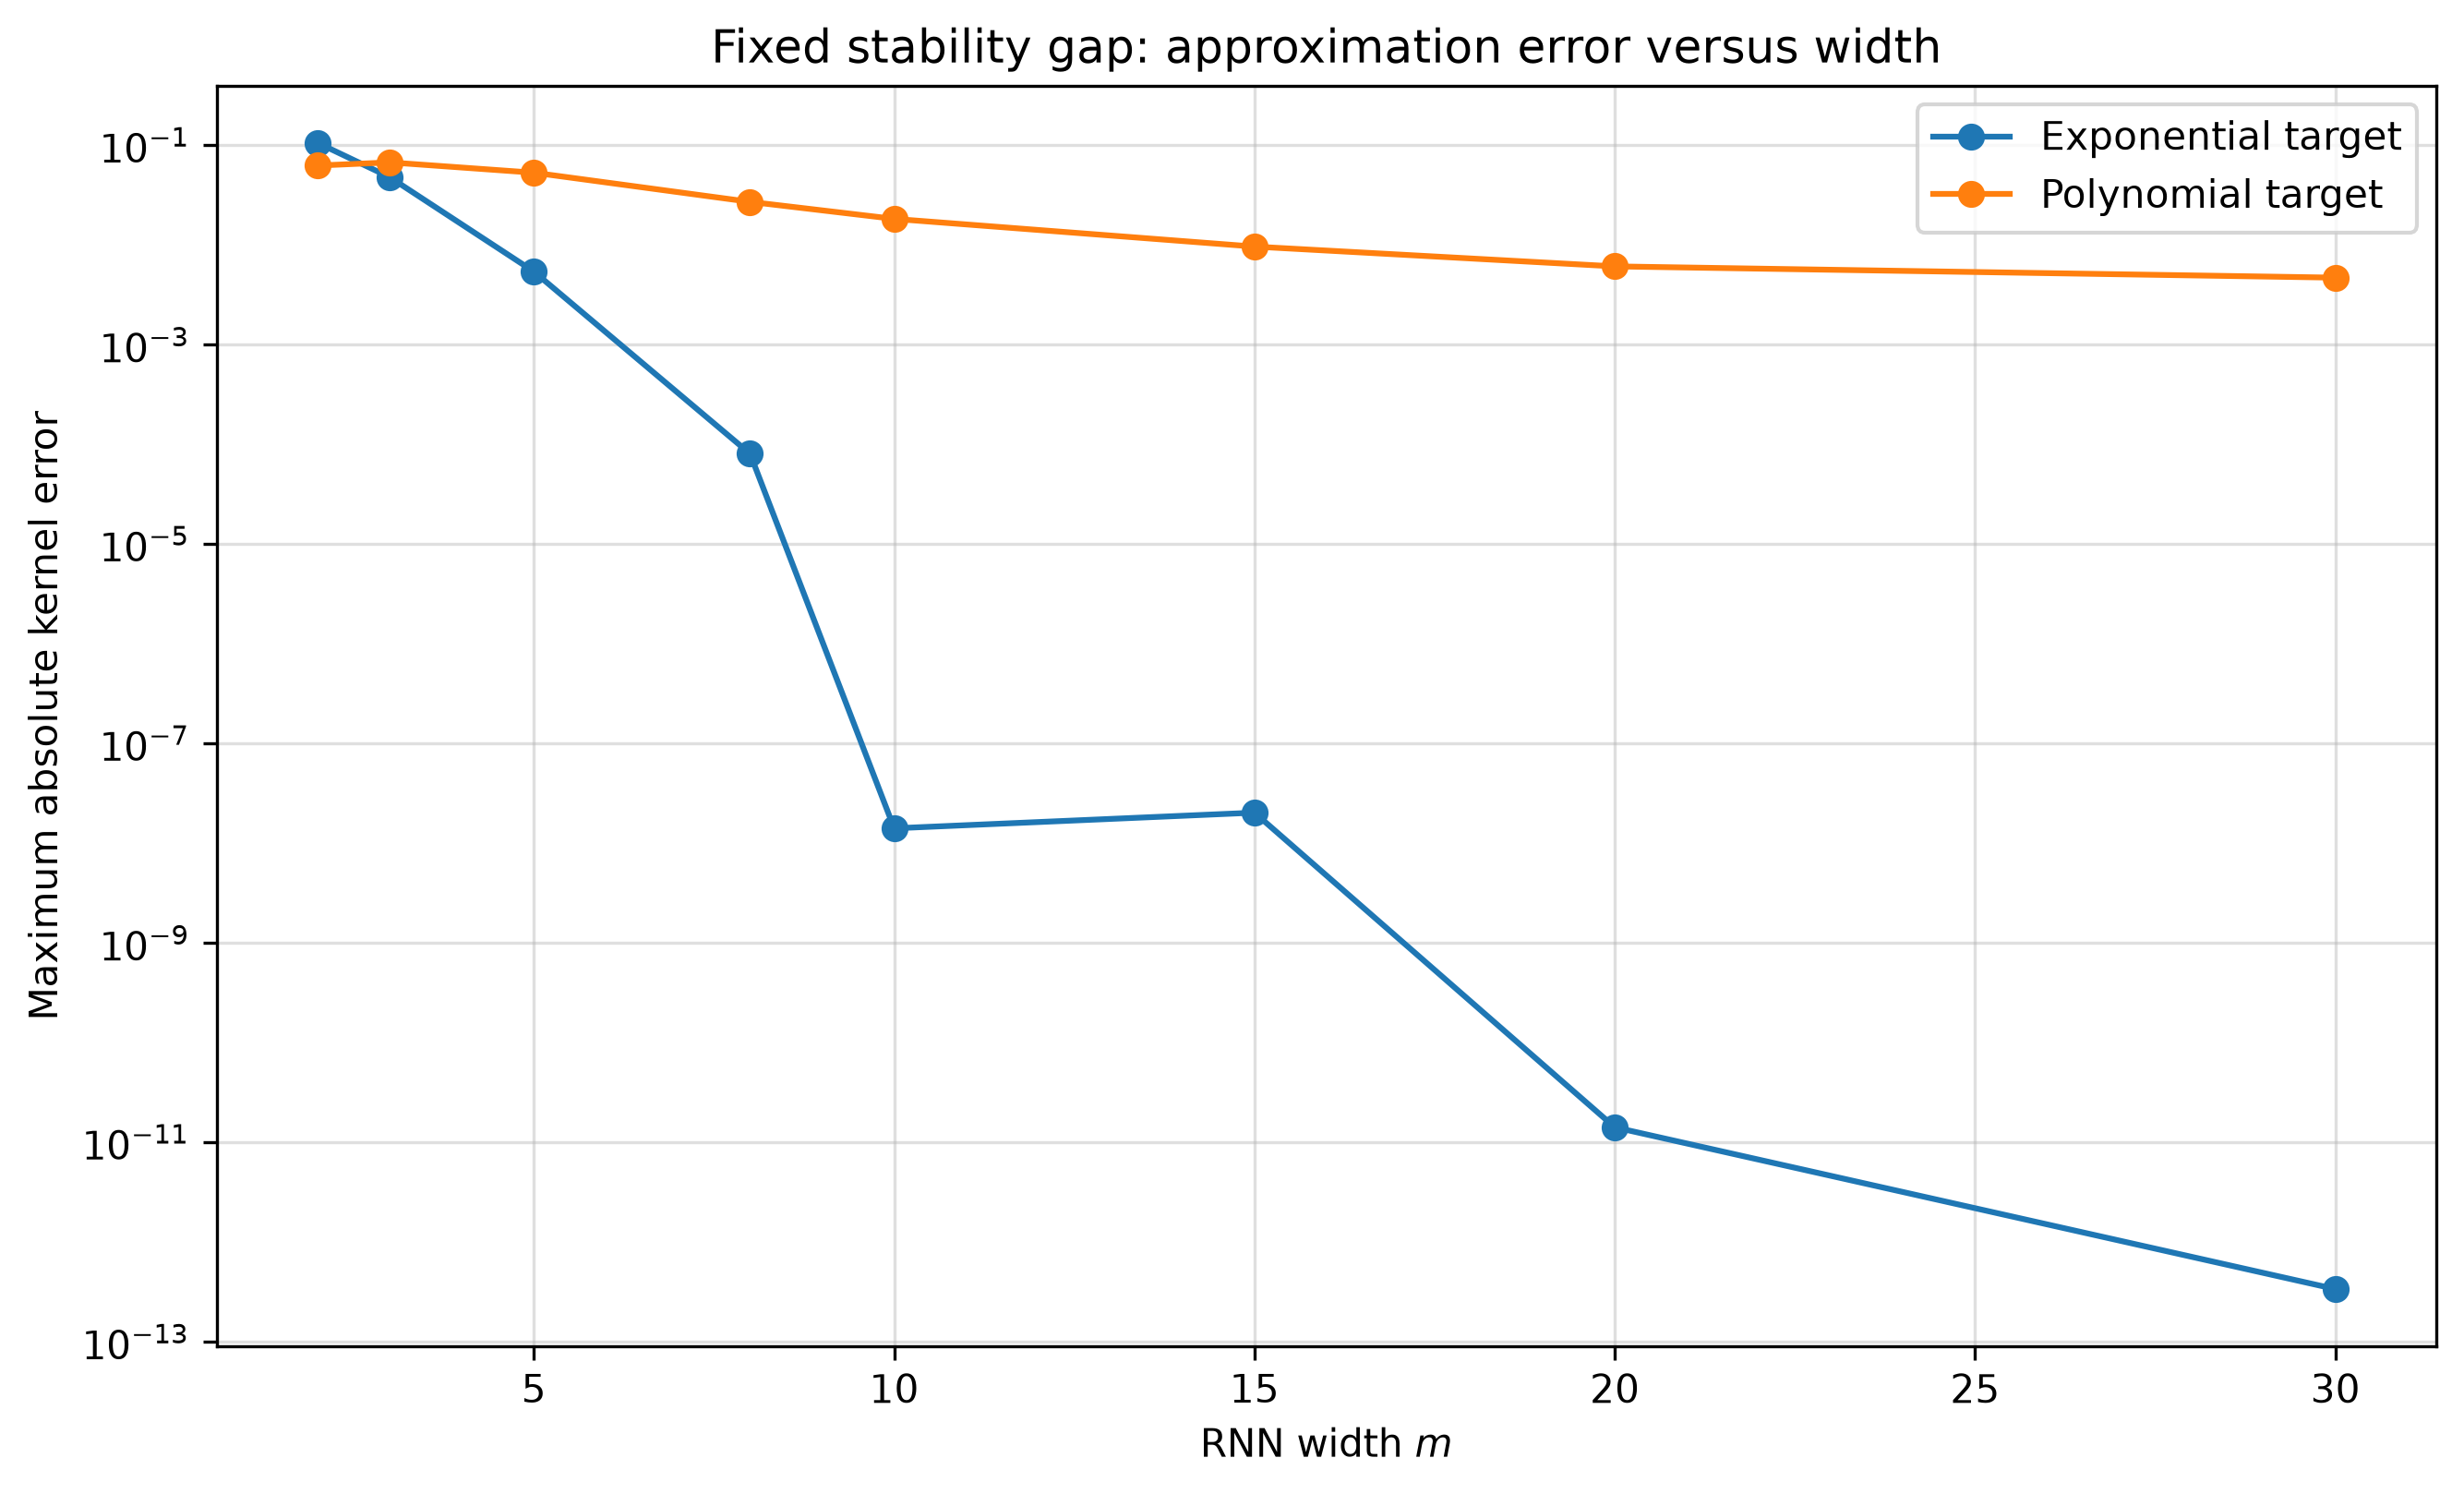

In [22]:
display(
    Image(
        filename=str(
            FIGURE_DIR
            / "theorem11_fixed_gap_target_comparison.png"
        ),
        width=20,
    )
)

### Interpretation

The exponential target is approximated increasingly well as the width $m$ grows. Its error decreases by many orders of magnitude and reaches approximately machine precision for large $m$. This is expected because the target itself belongs to the class of exponentially decaying kernels represented by the chosen basis.

For the polynomial target, the error decreases only slowly and appears to level off around $10^{-3}$. The fixed stability gap restricts all basis functions to decay at least as fast as $e^{-\beta t}$, whereas the target decays only polynomially. Increasing the width therefore improves the finite-interval fit, but it does not remove the mismatch in tail behavior.

The experiment illustrates the inverse statement behind Theorem 11: under a common stability margin, exponentially decaying targets are compatible with the model class, while slowly decaying targets remain fundamentally harder to approximate globally.

## 5. Weighted decay criterion

The theorem's conclusion is tested through

$$
e^{\beta t}|\rho(t)|.
$$

For the exponential target with $\beta=1$,

$$
e^{\beta t}\rho_{\exp}(t)=e^{-t}\to0.
$$

For the polynomial target,

$$
e^{\beta t}\rho_{\mathrm{poly}}(t)
=
\frac{e^t}{(1+t)^2}
\to\infty.
$$


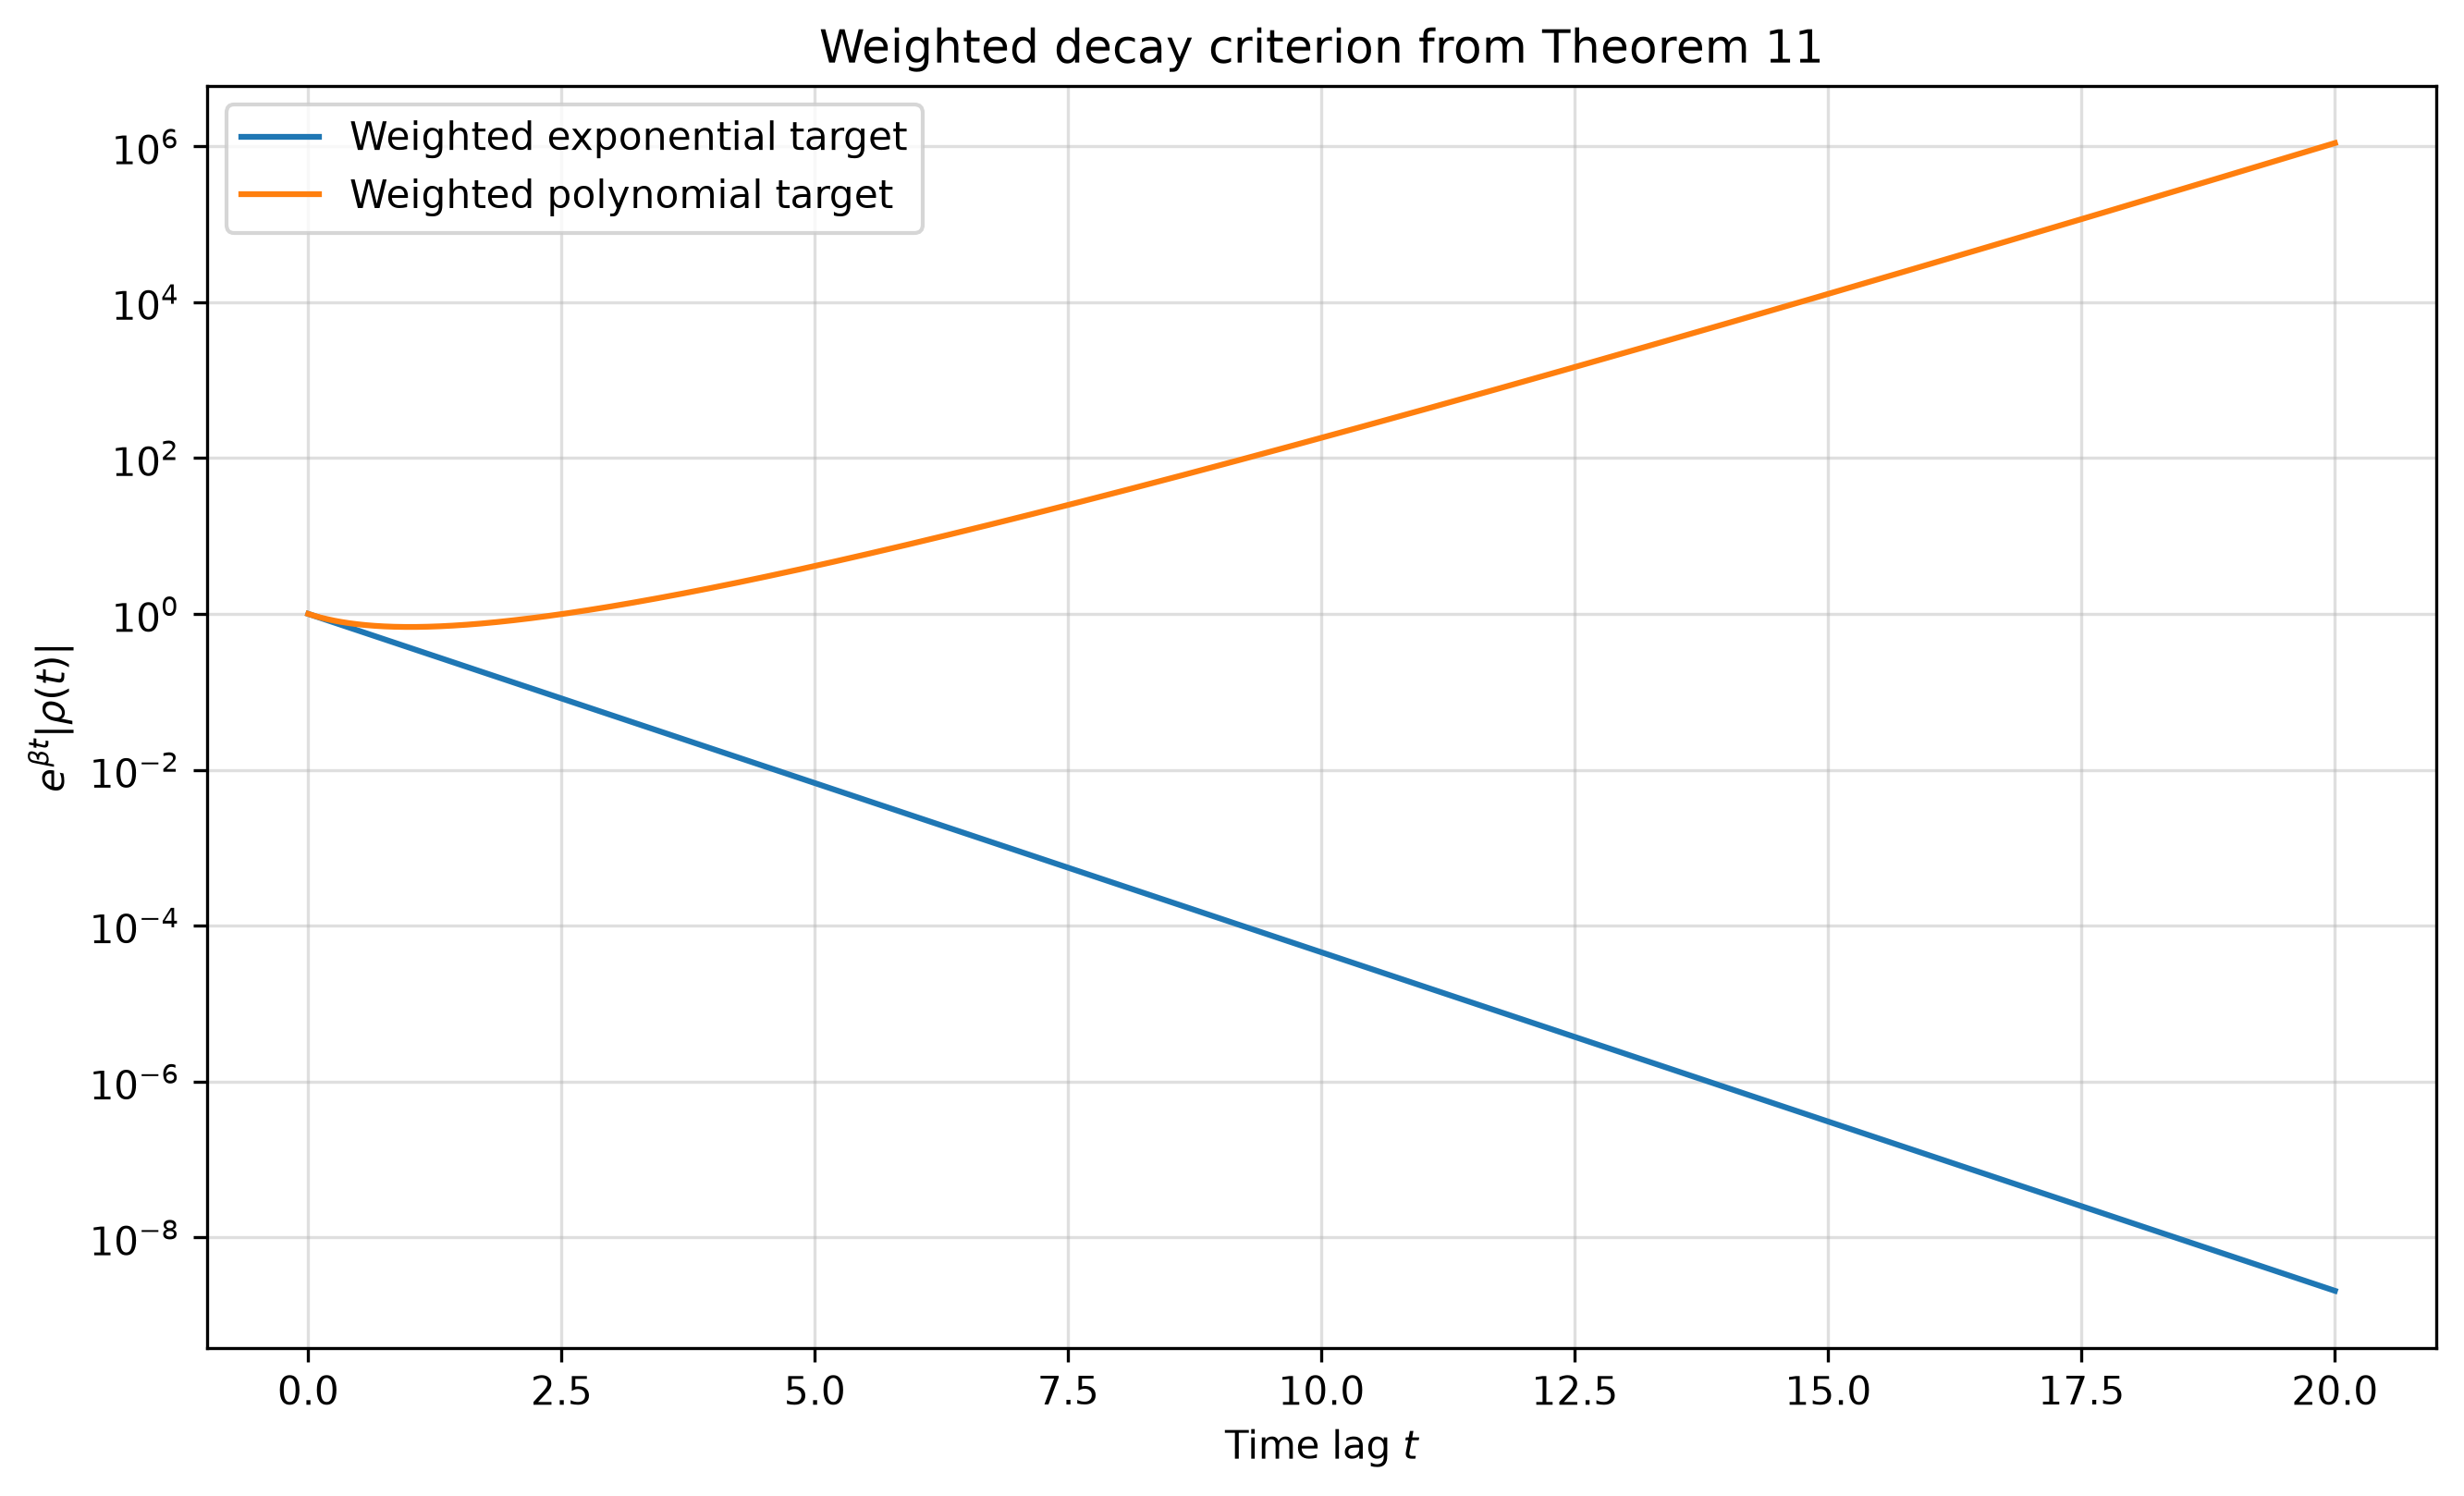

In [23]:
display(
    Image(
        filename=str(
            FIGURE_DIR
            / "theorem11_weighted_decay_criterion.png"
        )
    )
)


## 6. Role of the stability gap

Theorem 11 assumes a uniform stability margin,

$$
\limsup_{m\to\infty}\omega_m<-\beta,
\qquad
\omega_m
=
\max_{\mu\in\sigma(W_m)}
\operatorname{Re}(\mu).
$$

For the diagonal models used here, the eigenvalues are $-\lambda_j$. Hence

$$
\omega_m=-\lambda_{\min}.
$$

In the fixed-gap experiment we impose

$$
\lambda_j\ge\beta+\delta,
$$

with $\beta=1$ and $\delta=0.5$. Therefore,

$$
\omega_m
\le
-(\beta+\delta)
<
-\beta,
$$

so the assumptions of Theorem 11 are satisfied.

We now compare this setting with

$$
\lambda_{\min}(m)=\frac1m,
$$

where the stability gap vanishes as $m\to\infty$.

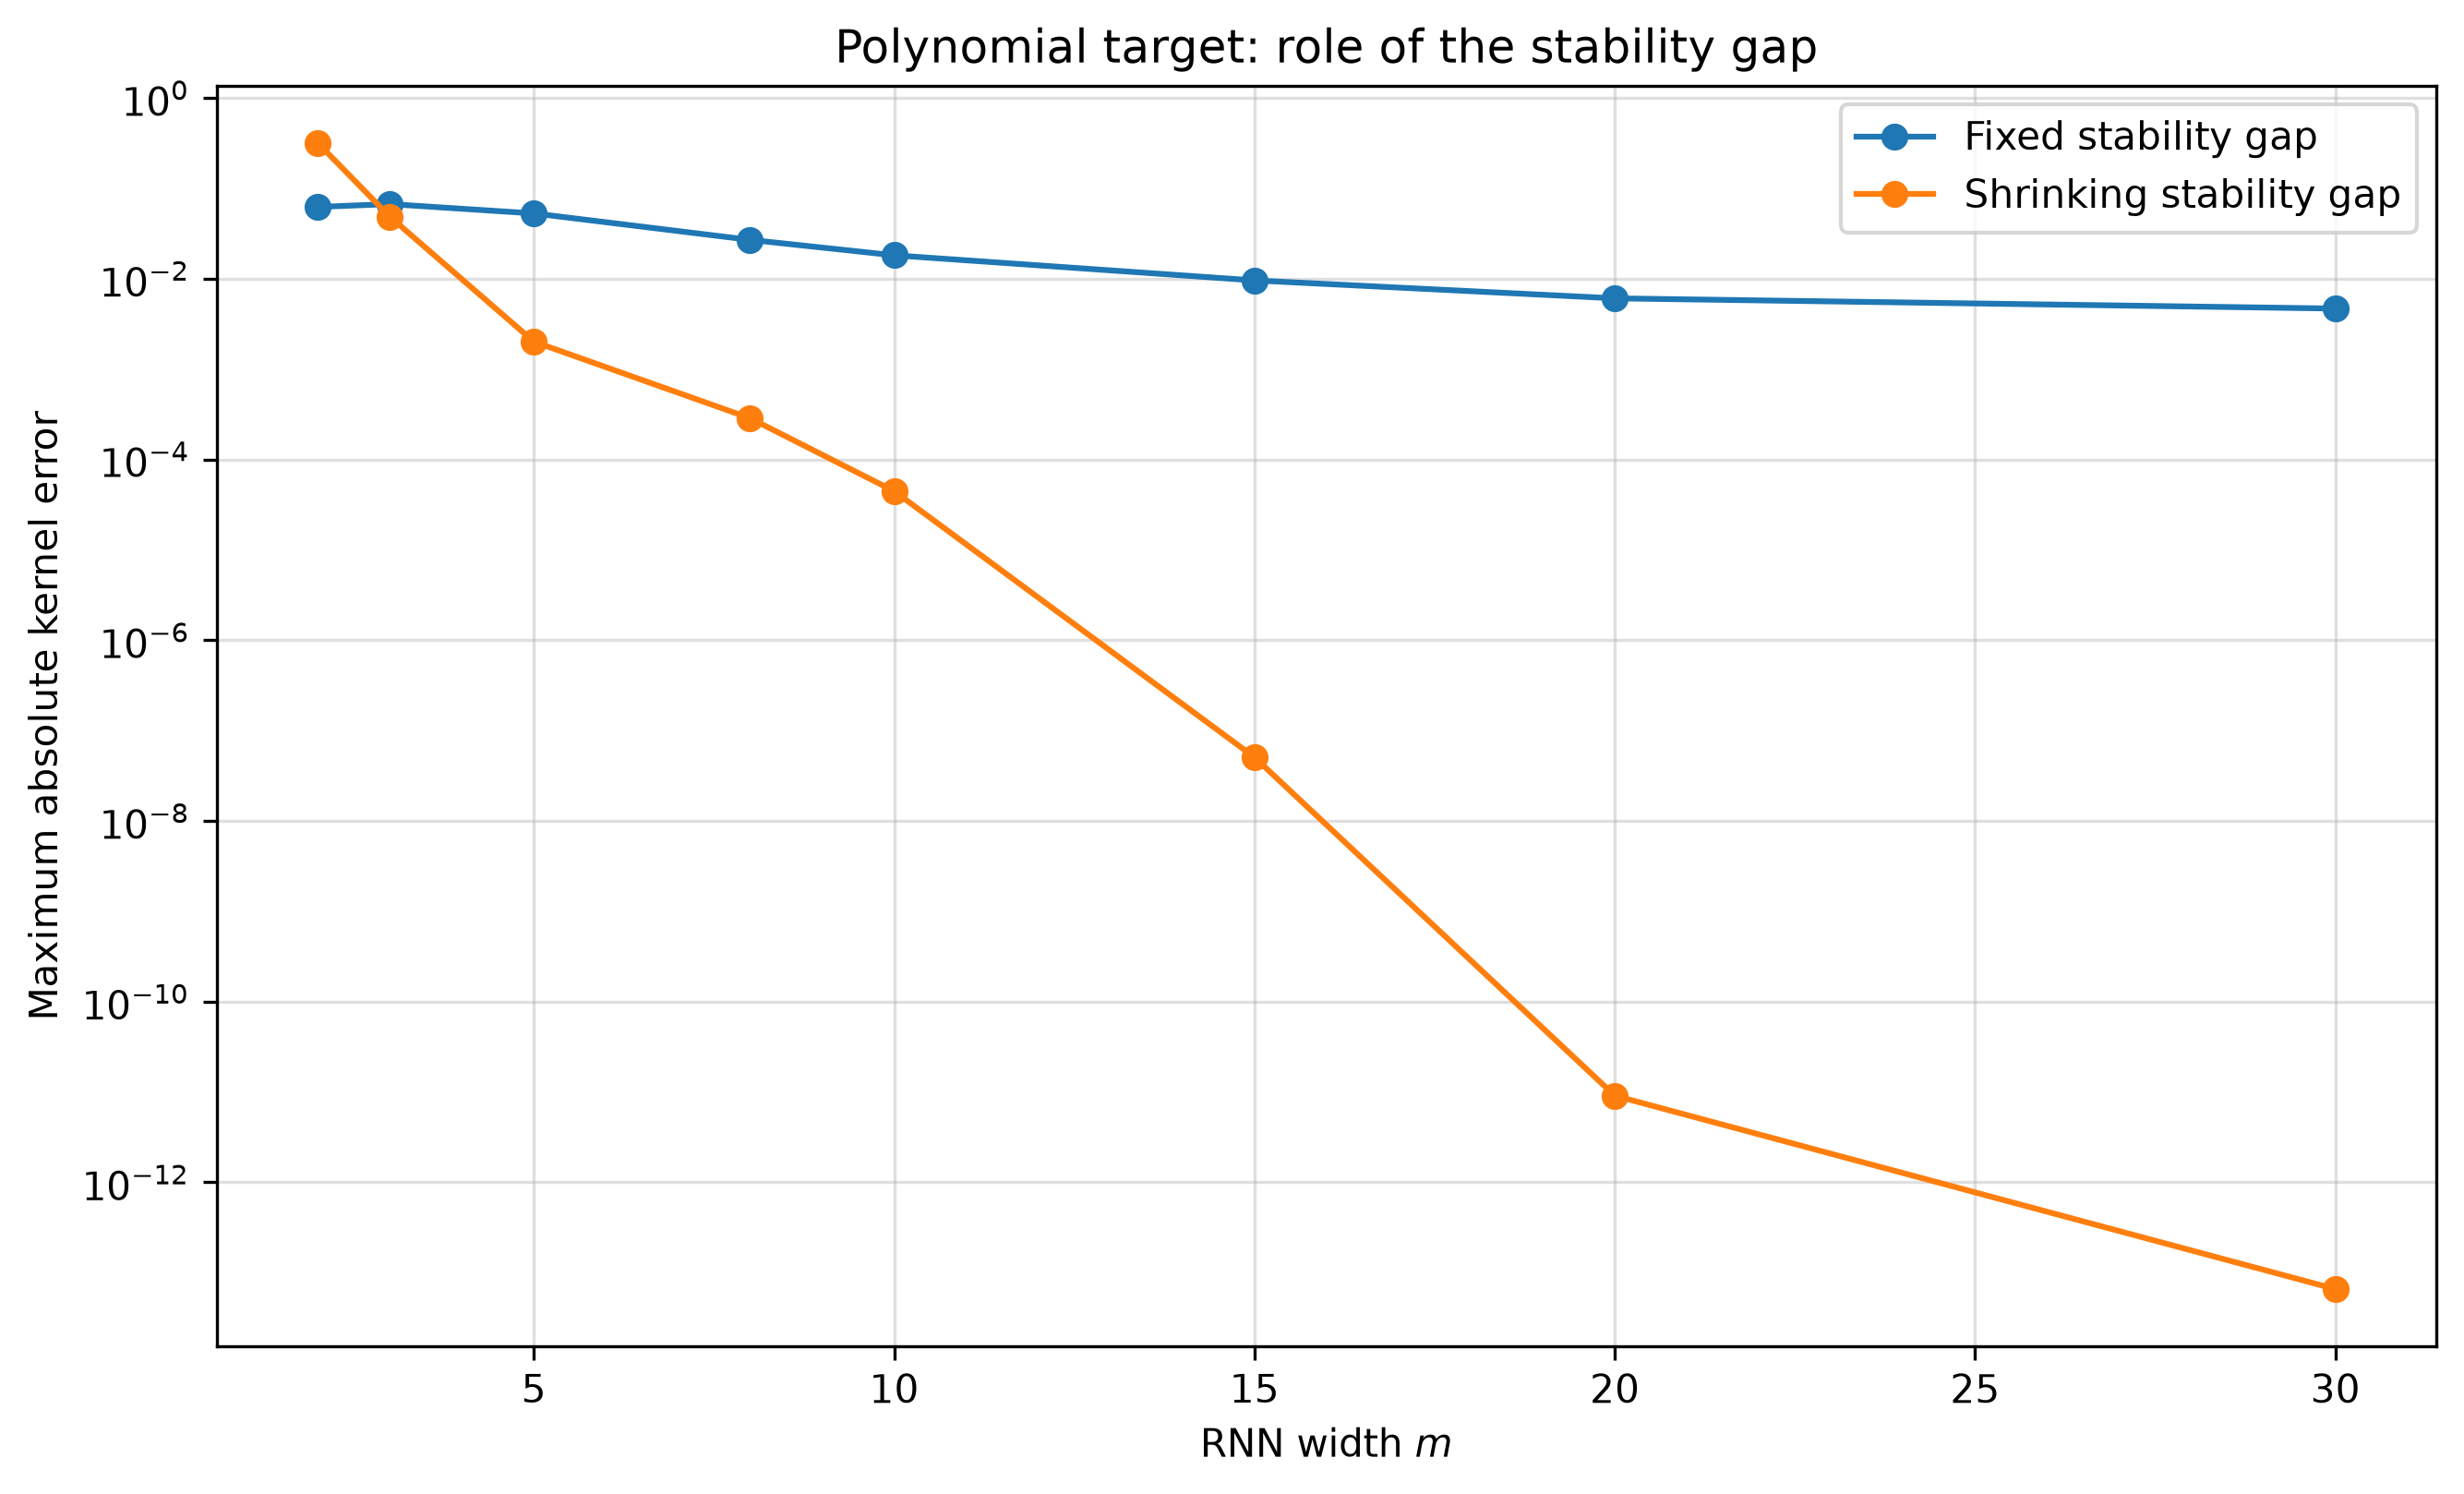

In [24]:

display(
    Image(
        filename=str(
            FIGURE_DIR
            / "theorem11_stability_gap_comparison.png"
        )
    )
)


### Interpretation

With a fixed stability gap, every admissible kernel satisfies a uniform exponential tail,

$$
\lambda_j\ge\beta+\delta.
$$

Consequently, polynomially decaying targets can only be approximated slowly.

Allowing

$$
\lambda_{\min}(m)=\frac1m\to0
$$

introduces increasingly slow exponential modes. The approximation error then decreases by many orders of magnitude.

Thus, removing the uniform stability gap substantially improves the finite-interval approximation. However, this violates the assumptions of Theorem 11, which require a common exponential stability margin.

Hence, the experiment illustrates that the stability-gap assumption is essential: it excludes arbitrarily slow exponential modes and thereby enforces the uniform exponential decay underlying the inverse result.

## 7. Numerical summary


In [25]:
summary = results.copy()

summary.columns = [
    "Width",
    "Exponential target, fixed gap",
    "Polynomial target, fixed gap",
    "Polynomial target, shrinking gap",
    "Smallest shrinking-gap rate",
]

summary


,Width,"Exponential target, fixed gap","Polynomial target, fixed gap","Polynomial target, shrinking gap",Smallest shrinking-gap rate
0,2,1.049484e-01,0.062161,3.181705e-01,0.500000
1,3,4.748446e-02,0.066869,4.863566e-02,0.333333
2,5,5.370102e-03,0.052703,2.008098e-03,0.200000
3,8,7.995522e-05,0.026870,2.855385e-04,0.125000
4,10,1.399187e-08,0.018135,4.450707e-05,0.100000
5,15,2.008813e-08,0.009562,5.053517e-08,0.066667
6,20,1.402256e-11,0.006055,9.087620e-12,0.050000
7,30,3.343992e-13,0.004668,6.583623e-14,0.033333


### Interpretation

The experiment illustrates why the uniform stability-gap assumption in Theorem 11 is essential.

With a fixed gap,

$$
\lambda_j\ge\beta+\delta,
$$

all admissible kernels possess a uniform exponential tail, whereas the polynomial target violates

$$
e^{\beta t}\rho_{\mathrm{poly}}(t)\to0.
$$

Allowing

$$
\lambda_{\min}(m)\to0
$$

introduces increasingly slow modes and yields a highly accurate approximation on the finite interval $[0,20]$.

Thus, the stability assumption is not merely technical: it enforces the uniform exponential decay required for the inverse conclusion of Theorem 11.

## 8. Limitations

- The kernels are synthetic and known explicitly.
- The fit is performed on the finite interval $[0,20]$.
- Only diagonal exponential bases are considered.
- The experiment studies approximation, not training from noisy input-output data.
- The shrinking-gap experiment demonstrates finite-interval approximation and does not imply exact global representation on $[0,\infty)$.


## 9. Reference

Li, Z., Han, J., E, W., and Li, Q. (2022).  
*Approximation and Optimization Theory for Linear Continuous-Time RNNs*.  
Journal of Machine Learning Research, 23.
